In [97]:
import numpy as np
import pandas as pd

In [98]:
class Perceptron:
    """Single-layer perceptron trained with the perceptron learning rule."""

    def __init__(self, n_features, lr=0.01):
        self.w = np.zeros(n_features)   # one weight per feature
        self.b = 0.0                    # bias
        self.lr = lr                    # learning rate

    def net_input(self, x):
        return x @ self.w + self.b

    def predict(self, X):
        # step activation: fire (1) when the net input is non-negative
        return (self.net_input(X) >= 0.0).astype(int)

    def fit(self, X, y, epochs):
        for _ in range(epochs):
            for xi, target in zip(X, y):
                pred = 1 if self.net_input(xi) >= 0.0 else 0
                error = target - pred           # -1, 0, or +1
                self.w += self.lr * error * xi
                self.b += self.lr * error
        return self


def accuracy(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

In [99]:
EPOCHS = [1, 5, 10, 15, 20, 50, 60, 80, 100, 120, 150, 200]


def load_xy(path):
    df = pd.read_csv(path)
    y = df["class"].to_numpy().astype(int)
    X = df.drop(columns="class").to_numpy(dtype=float)
    return X, y


def run_sweep(train_path, test_path, epochs_list=EPOCHS, lr=0.01):
    X_train, y_train = load_xy(train_path)
    X_test, y_test = load_xy(test_path)
    rows = []
    for n_epochs in epochs_list:
        model = Perceptron(X_train.shape[1], lr=lr)
        model.fit(X_train, y_train, n_epochs)
        rows.append({"# of epochs": f"{n_epochs}",
                     "Train": round(accuracy(y_train, model.predict(X_train)), 4),
                     "Test":  round(accuracy(y_test,  model.predict(X_test)),  4)})
    return pd.DataFrame(rows).set_index("# of epochs")

In [ ]:
seasyn_results = run_sweep("data/SeaSynTrain.csv", "data/SeaSynTest.csv")
seasyn_results

,Train,Test
# of epochs,,
1,0.65,0.625
5,0.75,0.700
10,0.69,0.600
15,0.85,0.850
20,0.72,0.625
50,0.73,0.650
60,0.71,0.600
80,0.70,0.625
100,0.72,0.625


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

X_sea_train, y_sea_train = load_xy("data/SeaSynTrain.csv")
X_sea_test,  y_sea_test  = load_xy("data/SeaSynTest.csv")

linear_baselines = []
for name, model in [("LogisticRegression", LogisticRegression(max_iter=10000, C=1e6)),
                    ("LinearSVC",          LinearSVC(C=1e6, max_iter=200000, dual=False))]:
    model.fit(X_sea_train, y_sea_train)
    linear_baselines.append({
        "Model": name,
        "Train": round(model.score(X_sea_train, y_sea_train), 4),
        "Test":  round(model.score(X_sea_test,  y_sea_test),  4),
    })
pd.DataFrame(linear_baselines).set_index("Model")

,Train,Test
Model,,
LogisticRegression,0.83,0.825
LinearSVC,0.85,0.850


In [102]:
ring_results = run_sweep("data/RingSynTrain.csv", "data/RingSynTest.csv")
ring_results

,Train,Test
# of epochs,,
1,0.6689,0.6567
5,0.6689,0.6567
10,0.7241,0.7200
15,0.6689,0.6567
20,0.6689,0.6567
50,0.7506,0.7500
60,0.6689,0.6567
80,0.6689,0.6567
100,0.6689,0.6567


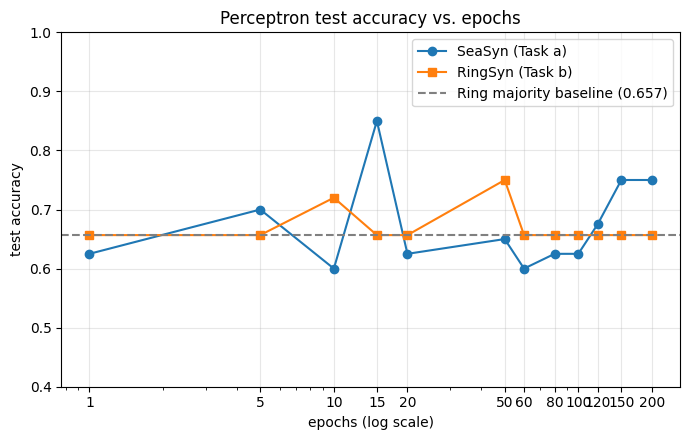

In [104]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(EPOCHS, sea_results["Test"].to_numpy(), marker="o", label="SeaSyn (Task a)")
ax.plot(EPOCHS, ring_results["Test"].to_numpy(), marker="s", label="RingSyn (Task b)")
ax.axhline(majority, ls="--", color="grey",
           label=f"Ring majority baseline ({majority:.3f})")
ax.set_xscale("log")
ax.set_xticks(EPOCHS)
ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.set_xlabel("epochs (log scale)")
ax.set_ylabel("test accuracy")
ax.set_title("Perceptron test accuracy vs. epochs")
ax.set_ylim(0.4, 1.0)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

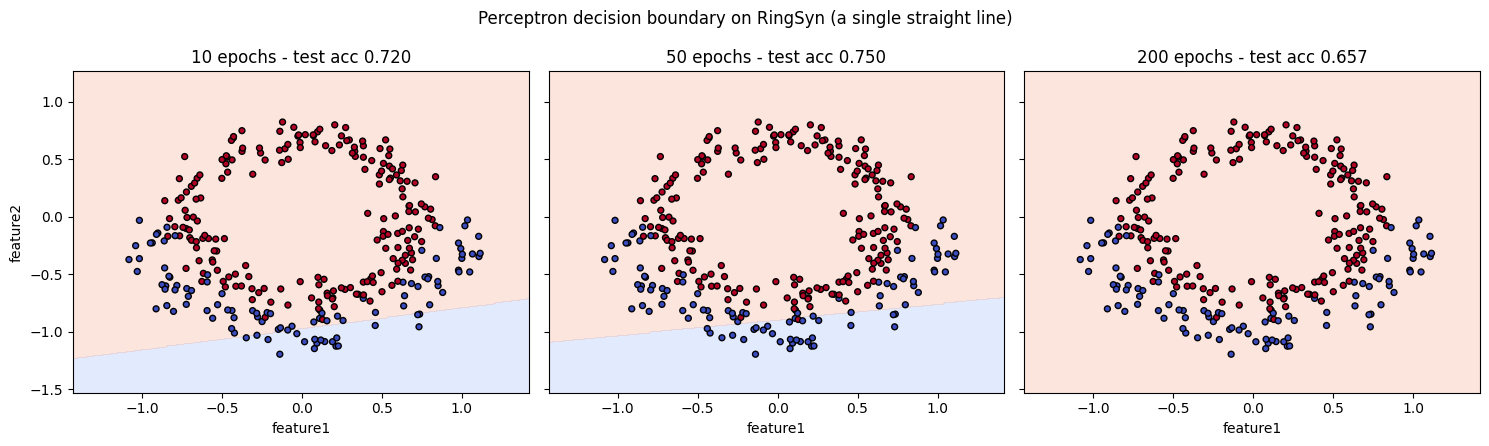

In [ ]:
# Train on the ring data and draw the (linear) decision boundary at three
# epoch counts: 10 (first non-degenerate split), 50 (the best the perceptron
# manages), and 200 (the endpoint, where the boundary has drifted off-screen).
Xr_train, yr_train = load_xy("data/RingSynTrain.csv")
Xr_test, yr_test = load_xy("data/RingSynTest.csv")

# A grid spanning the feature space, coloured by the perceptron's prediction.
x_min, x_max = Xr_train[:, 0].min() - 0.3, Xr_train[:, 0].max() + 0.3
y_min, y_max = Xr_train[:, 1].min() - 0.3, Xr_train[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, n_ep in zip(axes, [10, 50, 200]):
    model = Perceptron(2).fit(Xr_train, yr_train, n_ep)
    zz = model.predict(grid).reshape(xx.shape)
    acc = accuracy(yr_test, model.predict(Xr_test))
    # fixed levels so class 0 -> blue and class 1 -> red in *all* panels
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], alpha=0.25, cmap="coolwarm")
    ax.scatter(Xr_test[:, 0], Xr_test[:, 1], c=yr_test, cmap="coolwarm",
               vmin=0, vmax=1, edgecolor="k", s=18)
    ax.set_title(f"{n_ep} epochs - test acc {acc:.3f}")
    ax.set_xlabel("feature1")
axes[0].set_ylabel("feature2")
fig.suptitle("Perceptron decision boundary on RingSyn (a single straight line)")
plt.tight_layout()
plt.show()

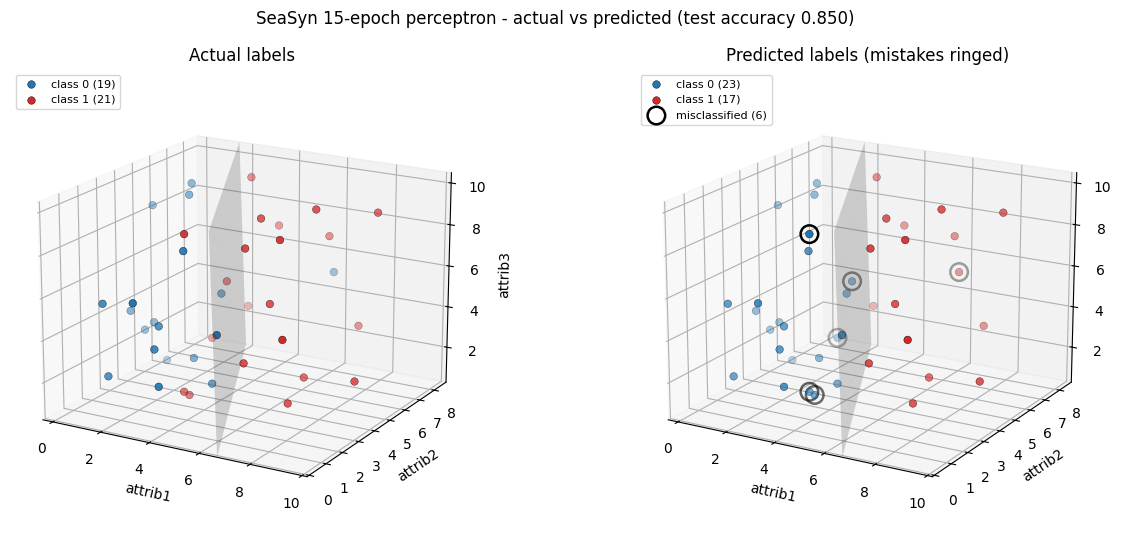

In [106]:
# Two 3D views of the SeaSyn test set under the 15-epoch perceptron:
#   Left  - test points coloured by their TRUE class.
#   Right - test points coloured by the model's PREDICTION, with each
#           misclassified point ringed in black.
# The grey surface is the perceptron's decision plane (class 1 above, class 0
# below). Reuses sea15, Xs_test, ys_test, preds, test_acc from the previous cell.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3-D projection)

class_colours = {0: "tab:blue", 1: "tab:red"}

# Decision-plane geometry: solve for the axis with the largest |weight| so
# the surface spans the data cleanly (same trick as the earlier 3D plot).
w15, b15 = sea15.w, sea15.b
axis = int(np.argmax(np.abs(w15)))
others = [j for j in range(3) if j != axis]
lo, hi = Xs_test.min(0) - 0.5, Xs_test.max(0) + 0.5
g1, g2 = np.meshgrid(np.linspace(lo[others[0]], hi[others[0]], 20),
                     np.linspace(lo[others[1]], hi[others[1]], 20))
solved = -(w15[others[0]] * g1 + w15[others[1]] * g2 + b15) / w15[axis]
coords = [None, None, None]
coords[axis], coords[others[0]], coords[others[1]] = solved, g1, g2


def _draw(ax, labels, title, ring_mask=None):
    for cls, c in class_colours.items():
        mask = labels == cls
        ax.scatter(Xs_test[mask, 0], Xs_test[mask, 1], Xs_test[mask, 2],
                   c=c, s=30, edgecolor="k", linewidth=0.3,
                   label=f"class {cls} ({mask.sum()})")
    if ring_mask is not None and ring_mask.any():
        ax.scatter(Xs_test[ring_mask, 0], Xs_test[ring_mask, 1],
                   Xs_test[ring_mask, 2],
                   facecolors="none", edgecolors="black",
                   s=160, linewidths=1.8,
                   label=f"misclassified ({ring_mask.sum()})")
    ax.plot_surface(coords[0], coords[1], coords[2], alpha=0.2, color="grey")
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
    ax.set_xlabel("attrib1"); ax.set_ylabel("attrib2"); ax.set_zlabel("attrib3")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    ax.view_init(elev=18, azim=-60)


fig = plt.figure(figsize=(13, 5.5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
_draw(ax1, ys_test, "Actual labels")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
_draw(ax2, preds, "Predicted labels (mistakes ringed)",
      ring_mask=(preds != ys_test))
fig.suptitle(f"SeaSyn 15-epoch perceptron - actual vs predicted "
             f"(test accuracy {test_acc:.3f})")
plt.tight_layout()
plt.show()